# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [39]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [ ]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE



Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [41]:
#Henry
class TwoThreeTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found    

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [42]:
class AVLTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found  

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [29]:
#Alfie 
from enum import Enum

class Color(Enum):
     BLACK = False
     RED = True


class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
        #False - black, True - red
        self.color = Color.BLACK  
    
    
class LLRBBST(): #AbstractSearchInterface
    def __init__(self):
        self.node = None

    def rotateLeft(self, n: Node):
        x = n.right
        n.right = x.left
        x.left = n
        x.color = n.color
        n.color = Color.RED

        return x
    
    def rotateRight(self, n: Node):
        x = n.left
        n.left = x.right
        x.right = n
        x.color = n.color
        n.color = Color.RED

        return x
    
    def flipColor(self, n: Node):
        n.color = Color.RED
        if n.left: n.left.color = Color.BLACK
        if n.right: n.right.color = Color.BLACK

    def putBST(self, element, n: Node):
        if n is None:
            newNode = Node(element)
            newNode.color = Color.RED
            return newNode
        
        if element == n.key: 
            return n
        if n == None: 
            n = Node(element)
            return n
        
        if element < n.key: 
            n.left = self.putBST(element, n.left)
        if element > n.key: 
            n.right = self.putBST(element, n.right)

        if (self.isRed(self.node.right) and not self.isRed(self.node.left)): self.node =  self.rotateLeft(self.node)
        if (self.isRed(self.node.left) and self.isRed(self.node.left.left)): self.node =  self.rotateRight(self.node)
        if (self.isRed(self.node.left) and self.isRed(self.node.right)): self.node = self.flipColor(self.node)

        return n

    def isRed(self, n: Node):
        return (n is not None and n.color == Color.RED)
         
    def insertElement(self, element):
        inserted = False
        self.node = self.putBST(element, self.node)
        self.node.color = Color.BLACK

        return inserted
    
    def printTree(self, n, level=0):
        if n is None:
            print("   " * level + "---")
            return

        print("   " * level + f"{n.key}: {n.color}")

        self.printTree(n.left, level + 1)
        self.printTree(n.right, level + 1)

    def searchElement(self, element):     
        found = False
        n = self.node
        
        while n is not None:
            if element == n.key: 
                found = True
                break 
            elif element < n.key: n = n.left
            else: n = n.right
        
        return found 


    def main(self):
        self.insertElement("B")
        self.insertElement("A")
        self.insertElement("C")
        self.insertElement("E")
        self.printTree(self.node)
        print(self.searchElement("C"))
    

LLRBBST().main()

B: Color.BLACK
   A: Color.BLACK
      ---
      ---
   C: Color.BLACK
      ---
      E: Color.RED
         ---
         ---
True


Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [44]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [ ]:
class ScapegoatTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [46]:
# Alex
import string
import random
from abc import ABC, abstractmethod

rand = random.Random(67) # for reproducibility

class StringNumber():

    def __init__(self, n: int = 0):
        self.n = n

    def __add__(self, other):
        if (isinstance(other, StringNumber)):
            return StringNumber(self.n + other.n)
        elif (isinstance(other, int)):
            return StringNumber(self.n + other)

    def __sub__(self, other):
        if (isinstance(other, StringNumber)):
            return StringNumber(self.n - other.n)
        elif (isinstance(other, int)):
            return StringNumber(self.n - other)
        
    def __radd__(self, other):
        return self.__add__(other)
    
    def __rsub__(self, other):
        return StringNumber(self.__sub__(other).n * -1)
    
    # In the spirit of ensuring data used is a string, we will use only strings that can actually be displayed in the terminal.
    # The number will be converted to a base (126-33 = 94) string that can be displayed.
    def __str__(self):
        nTemp  = self.n
        s = ""
        while nTemp > 0:
            s = chr((nTemp % 94) + 33) + s
            nTemp = nTemp // 94
        return s
    def __repr__(self):
        return self.__str__()

class FixedLengthRandomStringGenerator():

    def __next__(self):
        return "".join([chr(rand.randint(97,112)) for _ in range(8)]) # 128 bit entropy and short string so that equality checking does not affect results

    def __iter__(self):
        return self

class DecreasingStringGenerator():

    def __init__(self):
        self.n = StringNumber(10 ** 10) # we will probably not exceed this number, and it generates a small string

    def __next__(self):
        self.n-=1
        return str(self.n)
    
    def __iter__(self):
        return self

class IncreasingStringGenerator():

    def __init__(self):
        self.dec = DecreasingStringGenerator()
    
    def __next__(self):
        return next(self.dec)[::-1]
    
    def __iter__(self):
        return self

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [47]:
class DummySet(AbstractSearchInterface):
    def __init__(self):
        self.data = set()

    def insertElement(self, element):
        self.data.add(element)
    
    def searchElement(self, element):     
        return element in self.data


class TreeNode:
    __slots__ = ['element', 'left', 'right']
    def __init__(self, element):
        self.element = element
        self.left = None
        self.right = None


class BST(AbstractSearchInterface):
    def __init__(self):
        self.root = None

    def insertElement(self, element):
        # If the tree is empty, initialize the root
        if self.root is None:
            self.root = TreeNode(element)
            return True
        
        current = self.root
        while True:
            if element == current.element:
                # Element already exists
                return False
            
            elif element < current.element:
                # Go left
                if current.left is None:
                    current.left = TreeNode(element)
                    return True
                current = current.left
                
            else:
                # Go right
                if current.right is None:
                    current.right = TreeNode(element)
                    return True
                current = current.right

    def searchElement(self, element):
        current = self.root
        while current is not None:
            if element == current.element:
                return True
            elif element < current.element:
                current = current.left
            else:
                current = current.right
        return False
class TwoThreeNode:
    """A node for the 2-3 Tree. It can hold 1 or 2 keys, and 0, 2, or 3 children."""
    __slots__ = ['keys', 'children']
    
    def __init__(self):
        self.keys = []
        self.children = []
        
    def is_leaf(self):
        return len(self.children) == 0


class TwoThreeTree(AbstractSearchInterface):
    """
    A 2-3 Tree implementation. 
    Maintains perfect balance, guaranteeing O(log N) worst-case performance.
    """
    def __init__(self):
        self.root = None

    def searchElement(self, element):
        """
        Search for an element iteratively.
        Returns True if found, False otherwise.
        """
        if self.root is None:
            return False
            
        current = self.root
        while current is not None:
            if element in current.keys:
                return True
                
            if current.is_leaf():
                return False
                
            # Find the correct child branch to follow
            idx = 0
            while idx < len(current.keys) and element > current.keys[idx]:
                idx += 1
            current = current.children[idx]
            
        return False

    def insertElement(self, element):
        """
        Insert an element in the 2-3 Tree.
        Returns True if successful, False if the element is already present.
        """
        # 1. Empty tree case
        if self.root is None:
            self.root = TwoThreeNode()
            self.root.keys.append(element)
            return True
            
        # 2. Duplicate check (O(log N) cost, very fast)
        if self.searchElement(element):
            return False
            
        # 3. Perform the recursive insertion
        promoted_key, right_sibling = self._insert(self.root, element)
        
        # 4. If the root itself split, we must create a new root, increasing tree height
        if promoted_key is not None:
            new_root = TwoThreeNode()
            new_root.keys.append(promoted_key)
            new_root.children.append(self.root)
            new_root.children.append(right_sibling)
            self.root = new_root
            
        return True

    def _insert(self, node, element):
        """
        Recursive helper for insertion.
        Returns (promoted_key, right_node) if this node splits.
        Returns (None, None) if the insertion was absorbed without overflowing.
        """
        if node.is_leaf():
            # Insert the new key into this leaf and keep it sorted
            node.keys.append(element)
            node.keys.sort()
        else:
            # Find which child to traverse down
            idx = 0
            while idx < len(node.keys) and element > node.keys[idx]:
                idx += 1
            
            promoted_key, right_sibling = self._insert(node.children[idx], element)
            
            # If the child split, we must absorb its promoted key and new sibling
            if promoted_key is not None:
                node.keys.insert(idx, promoted_key)
                node.children.insert(idx + 1, right_sibling)
        
        # Check if this node has overflowed (contains 3 keys)
        if len(node.keys) == 3:
            return self._split(node)
            
        return None, None

    def _split(self, node):
        """
        Splits a node that has 3 keys into two nodes.
        Modifies the current node to keep the left half, returns the middle key and right half.
        """
        mid_key = node.keys[1]
        
        # Create the new right node
        right_node = TwoThreeNode()
        right_node.keys.append(node.keys[2])
        
        # If not a leaf, we must also divide the 4 children between the two nodes
        if not node.is_leaf():
            right_node.children.extend(node.children[2:])
            node.children = node.children[:2]
            
        # The current node keeps only the left key
        node.keys = [node.keys[0]]
        
        return mid_key, right_node

<module 'matplotlib.pyplot' from 'C:\\Users\\alexz\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\matplotlib\\pyplot.py'>

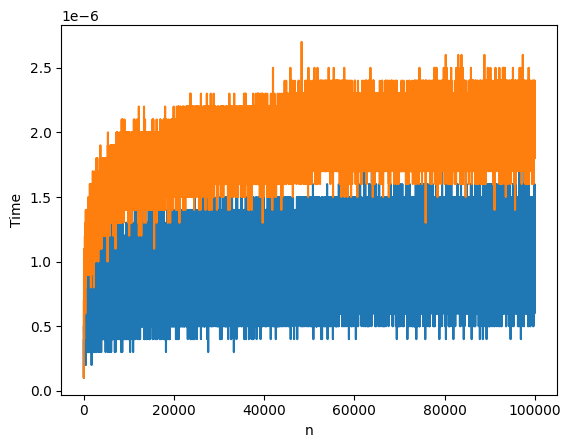

In [ ]:
# Alex
import timeit
import matplotlib.pyplot as plt
import math

KILO = 10 ** 3
MEGA = 10 ** 6
GIGA = 10 ** 9




class Plotter():
    def __init__(self, x,y):
        self.x = x
        self.y = y
        self.xlabel = 'n'
        self.ylabel = 'Time'

    def fromTupledPoints(pts):
        x,y = zip(*pts)
        return Plotter(x,y)
    
    def add_tupled_points(self, pts):
        x,y = zip(*pts)
        plt.plot(x,y)
        return self
    
    def add_points(self, x,y):
        plt.plot(x,y)
        return self
    
    def plotting_log(self):
        self.x = [math.log(i) for i in self.x]
        self.xlabel ='logn'
        return self
    
    def plotting_constant(self):
        self.y = [v / math.log(self.x[k]) for k,v in enumerate(self.y)]
        self.ylabel = 'Time/logn'
        return self
    
    def make_plot(self):
        plt.plot(self.x, self.y)
        plt.ylabel(self.ylabel)
        plt.xlabel(self.xlabel)
        return plt


class ExperimentalFramework():
    def __init__(self, set : AbstractSearchInterface):
        self.set = set

    """
    https://docs.python.org/3/library/timeit.html#:~:text=Note%20It%E2%80%99s,statistics
    """
    def reduce_min(self, pts_list):
        n = len(pts_list)
        return [(pts_list[0][i][0], min(pts_list[j][i][1] for j in range(n))) for i in range(len(pts_list[0]))]
    def floor_log10(n):
        if n == 0:
            return 0
        log = 0
        power = 1
        while power <= n:
            log += 1
            power *= 10
        return log - 1
    

    def time_insert(self, strings, a, b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        for _ in range(0, a):
            self.set.insertElement(next(gen))
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            start = timeit.default_timer()
            self.set.insertElement(s) 
            end = timeit.default_timer()
            pts.append((i, end-start))
        return pts
    
    def time_insert_amortised(self, strings,a,b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        if a > 0:
            pre_insert = timeit.default_timer()
            for _ in range(0, a):
                self.set.insertElement(next(gen))
            pre_insert = timeit.default_timer() - pre_insert
        else:
            pre_insert = 0
        total_time = pre_insert
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            start = timeit.default_timer()
            self.set.insertElement(s)
            end = timeit.default_timer()
            total_time += (end - start)
            pts.append((i, total_time / i))
        return pts
    
    def time_search(self, strings,a,b):
        gen = iter(strings)
        self.set = type(self.set)() # empty set
        for _ in range(0, a):
            self.set.insertElement(next(gen))
        pts = []
        for i in range(a,b +1):
            s = next(gen)
            self.set.insertElement(s) # ensure the element is present for search
            start = timeit.default_timer()
            self.set.searchElement(s)
            end = timeit.default_timer()
            pts.append((i, end-start))
        return pts
    
    def plot_action(self, gen_type, action, a=1, b=GIGA, n=10):
        all_pts = []
        strings = [next(gen_type) for _ in range(0, b + 1)] # precache strings
        for _ in range(n):
            all_pts.append(action(strings, a, b))
        return Plotter.fromTupledPoints(self.reduce_min(all_pts))

exp = ExperimentalFramework(BST())
exp2 = ExperimentalFramework(TwoThreeTree())
exp.plot_action(FixedLengthRandomStringGenerator(),exp.time_search,a=1,b=KILO*100,n=10).make_plot()
exp2.plot_action(FixedLengthRandomStringGenerator(),exp2.time_search,a=1,b=KILO*100,n=10).make_plot()

# take top 2% and bottom 2%, divide by logn and plot log to show boundedness
#exp.plot_worst_case_search(b=MEGA)
    

Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

In [49]:
# ADD YOUR TEST CODE HERE 



